# Customer Churn Prediction with a PyTorch MLP

This notebook builds an end-to-end, production-oriented Multi-Layer Perceptron (MLP) for binary customer churn prediction. It includes:

- Exploratory data checks and leakage-safe preprocessing
- Numeric standardization and categorical one-hot encoding
- Custom PyTorch datasets and data loaders
- A batch-normalized, dropout-regularized MLP
- Validation tracking, early stopping, and checkpointing
- Test-set classification metrics, a confusion matrix, and ROC-AUC evaluation

The input data is expected to contain a binary target column named `churn` (the implementation also accepts `Churn` case-insensitively).

In [1]:
# Core imports and reproducibility configuration.
import copy
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Training device: {DEVICE}")

PyTorch version: 2.7.1+cu118
Training device: cuda


In [2]:
# Load the fixed train, validation, and test splits.
train_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\train_churn_dataset.csv")
val_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\val_churn_dataset.csv")
test_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\test_churn_dataset.csv")

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (314599, 13)
Validation shape: (67414, 13)
Test shape: (67415, 13)


In [20]:
# Set target column and identify feature columns
TARGET = "Churn"
feature_names = [col for col in train_df.columns if col != TARGET]

# Prepare training, validation, and test datasets for TabNet
X_train_raw = train_df[feature_names].astype(np.float32)
y_train = train_df[TARGET].astype(np.int64)

X_val_raw = val_df[feature_names].astype(np.float32)
y_val = val_df[TARGET].astype(np.int64)

X_test_raw = test_df[feature_names].astype(np.float32)
y_test = test_df[TARGET].astype(np.int64)

print(f"Positive churn rate: train={y_train.mean():.3f}, validation={y_val.mean():.3f}, test={y_test.mean():.3f}")

Positive churn rate: train=0.500, validation=0.500, test=0.500


In [23]:
# Fit preprocessing on the training split only, then transform all splits.
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

transformers = [("numeric", numeric_pipeline, numeric_features)]

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_val = preprocessor.transform(X_val_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)
feature_names = preprocessor.get_feature_names_out()

print(f"Numeric features: {len(numeric_features)}")
print(f"Transformed feature count: {X_train.shape[1]}")
print(f"Any NaNs after preprocessing: {np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any()}")

Numeric features: 12
Transformed feature count: 12
Any NaNs after preprocessing: False


In [12]:
# Custom dataset and data loaders for each split.
class ChurnDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: pd.Series):
        self.features = torch.as_tensor(features, dtype=torch.float32)
        self.targets = torch.as_tensor(targets.to_numpy(), dtype=torch.float32).view(-1, 1)

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, index: int):
        return self.features[index], self.targets[index]

BATCH_SIZE = 1024
train_loader = DataLoader(ChurnDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(ChurnDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(ChurnDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
print(f"Batches: train={len(train_loader)}, validation={len(val_loader)}, test={len(test_loader)}")

Batches: train=308, validation=66, test=66


In [33]:
# Define the MLP architecture and optimization objects.
class ChurnMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 1),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)

model = ChurnMLP(input_dim=X_train.shape[1]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
print(model)

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [34]:
# Reusable epoch routines. Validation runs with gradients disabled.
def run_epoch(model, loader, loss_function, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_items = 0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for features, targets in loader:
            features, targets = features.to(DEVICE), targets.to(DEVICE)
            logits = model(features)
            loss = loss_function(logits, targets)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            batch_size = features.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size
    return total_loss / total_items

history = {"train_loss": [], "val_loss": []}
print("Training helpers are ready.")

Training helpers are ready.


In [ ]:
# Train with validation-loss early stopping and save the best checkpoint.
MAX_EPOCHS = 20
PATIENCE = 5
CHECKPOINT_PATH = "mlp_churn_best.pt"
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer)
    val_loss = run_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "input_dim": X_train.shape[1],
            "feature_names": feature_names.tolist(),
            "best_val_loss": best_val_loss,
            "epoch": epoch,
        }, CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after epoch {epoch}.")
        break

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} with validation loss {checkpoint['best_val_loss']:.4f}.")

Epoch 01/20 | train loss: 0.3310 | val loss: 0.2766
Epoch 02/20 | train loss: 0.2797 | val loss: 0.2605


KeyboardInterrupt: 

In [32]:
# Generate test probabilities and predictions from the best checkpoint.
def predict_probabilities(model, loader):
    model.eval()
    probabilities = []
    with torch.no_grad():
        for features, _ in loader:
            logits = model(features.to(DEVICE))
            probabilities.append(torch.sigmoid(logits).cpu().numpy().ravel())
    return np.concatenate(probabilities)

test_prob = predict_probabilities(model, test_loader)
THRESHOLD = 0.5
test_pred = (test_prob >= THRESHOLD).astype(np.int64)
y_test_array = y_test.to_numpy().astype(np.int64)

print("Test ROC-AUC:", f"{roc_auc_score(y_test_array, test_prob):.4f}")
print("\nClassification report:")
print(classification_report(y_test_array, test_pred, target_names=["No Churn", "Churn"], digits=4, zero_division=0))

Test ROC-AUC: 0.9502

Classification report:
              precision    recall  f1-score   support

    No Churn     0.9853    0.8588    0.9177     33708
       Churn     0.8749    0.9872    0.9276     33707

    accuracy                         0.9230     67415
   macro avg     0.9301    0.9230    0.9227     67415
weighted avg     0.9301    0.9230    0.9227     67415



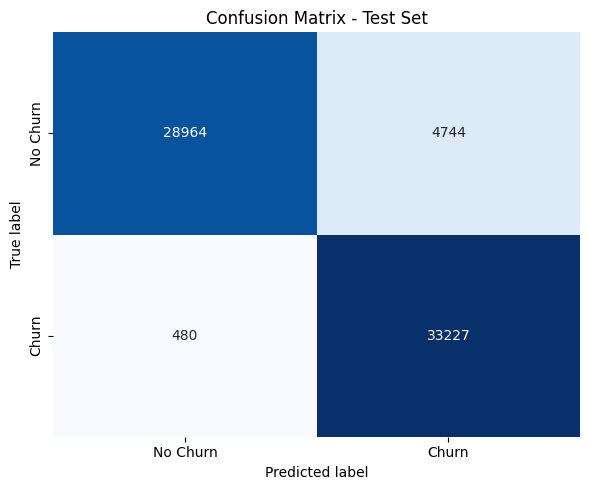

In [17]:
# Formatted confusion matrix on the held-out test set.
cm = confusion_matrix(y_test_array, test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

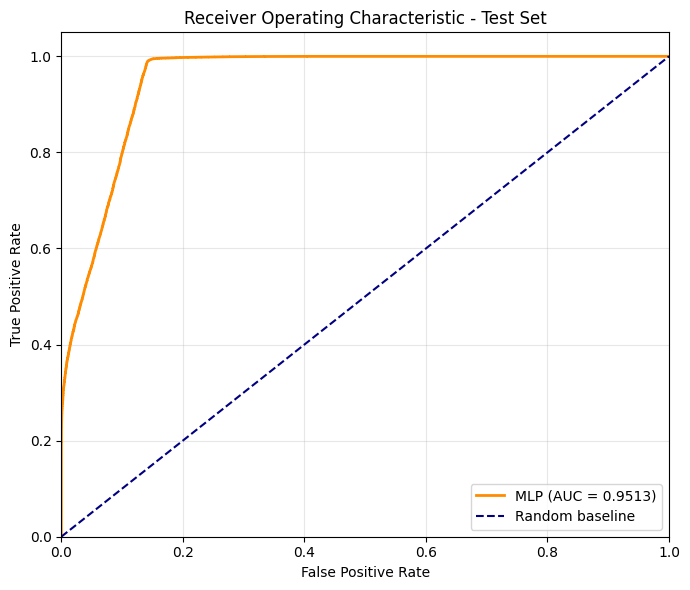

Test AUC: 0.9513


In [18]:
# ROC curve and AUC on the held-out test set.
fpr, tpr, _ = roc_curve(y_test_array, test_prob)
test_auc = roc_auc_score(y_test_array, test_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"MLP (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random baseline")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic - Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Test AUC: {test_auc:.4f}")

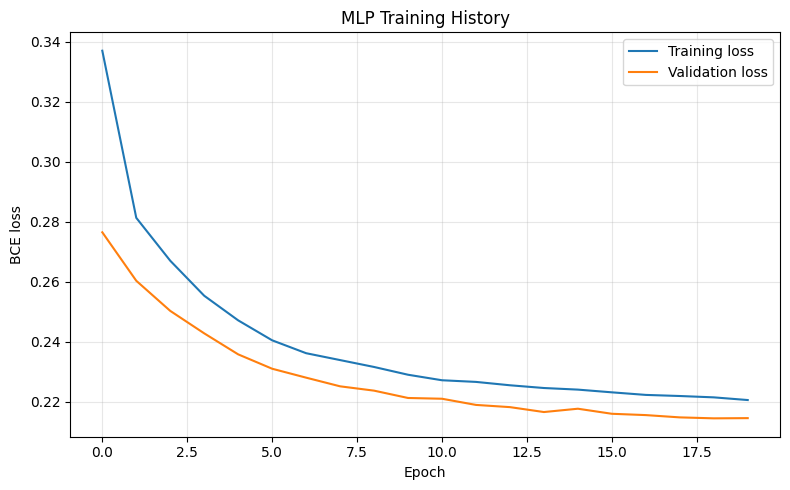

In [19]:
# Inspect training and validation loss to diagnose under/overfitting.
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("MLP Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Save the model and preprocessing object together for reproducible inference.
import joblib

ARTIFACT_DIR = "mlp_churn_artifacts"
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": X_train.shape[1],
    "feature_names": feature_names.tolist(),
    "threshold": THRESHOLD,
}, f"{ARTIFACT_DIR}_model.pt")
joblib.dump(preprocessor, f"{ARTIFACT_DIR}_preprocessor.joblib")
print(f"Saved model to {ARTIFACT_DIR}_model.pt")
print(f"Saved preprocessing pipeline to {ARTIFACT_DIR}_preprocessor.joblib")

Saved model to mlp_churn_artifacts_model.pt
Saved preprocessing pipeline to mlp_churn_artifacts_preprocessor.joblib


## Summary

The notebook now provides a complete leakage-safe MLP workflow:

1. Inspect the fixed train, validation, and test splits.
2. Impute missing values, standardize numeric features, and one-hot encode categorical features using training-fitted preprocessing.
3. Train a regularized PyTorch MLP with validation-loss early stopping.
4. Restore the best checkpoint and evaluate the untouched test set.
5. Report precision, recall, F1-score, support, confusion matrix, and ROC-AUC.
6. Save both the model weights and preprocessing pipeline for future inference.

For new records, load `mlp_churn_artifacts_model.pt` and `mlp_churn_artifacts_preprocessor.joblib`, apply the same preprocessing, and pass the resulting tensor through `ChurnMLP`.